In [1]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import os, cv2, torch, torch.nn as nn
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from glob import glob
from tqdm.auto import tqdm
from PIL import Image
from sklearn.model_selection import train_test_split
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

# Set device to GPU T4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Find CSV and images
csv_path = glob('/kaggle/input/**/Data_Entry_2017.csv', recursive=True)[0]
all_image_paths = {os.path.basename(x): x for x in glob('/kaggle/input/**/*.png', recursive=True)}

print(f"✅ Setup Complete. Using Accelerator: {device}")

✅ Setup Complete. Using Accelerator: cuda


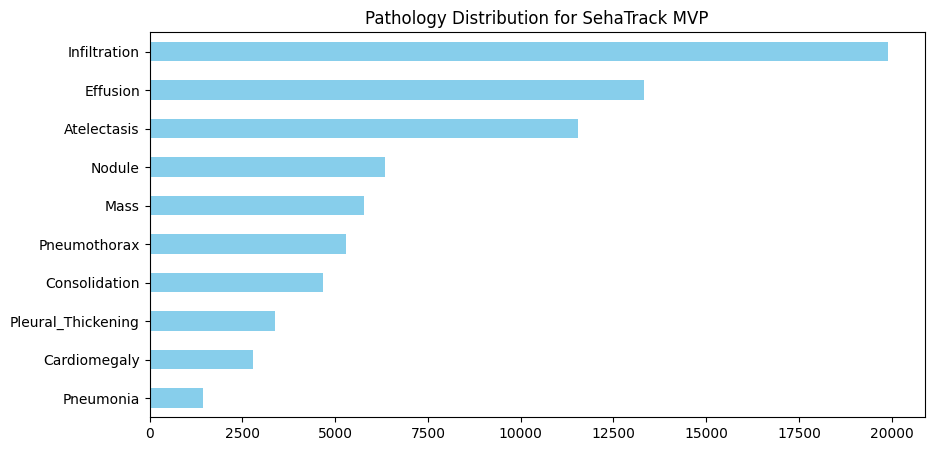

In [3]:
df = pd.read_csv(csv_path)
df = df[df['Image Index'].isin(all_image_paths.keys())].reset_index(drop=True)

# 1. Define Labels & Multi-label Encoding
disease_labels = ['Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration', 'Mass', 
                  'Nodule', 'Pneumonia', 'Pneumothorax', 'Consolidation', 'Pleural_Thickening']

for label in disease_labels:
    df[label] = df['Finding Labels'].apply(lambda x: 1 if label in x else 0)

# 2. Clinical Cleaning: Age and Gender
df = df[df['Patient Age'] <= 100] # Remove outliers
df['Normalized Age'] = df['Patient Age'] / 100.0
df['Gender_Code'] = df['Patient Gender'].map({'M': 0, 'F': 1}).fillna(0)

# 3. EDA Visualization: Disease Prevalence
plt.figure(figsize=(10, 5))
df[disease_labels].sum().sort_values().plot(kind='barh', color='skyblue')
plt.title("Pathology Distribution for SehaTrack MVP")
plt.show()

# 4. Patient-Level Split (Crucial to prevent data leakage)
unique_patients = df['Patient ID'].unique()
train_pts, val_pts = train_test_split(unique_patients, test_size=0.2, random_state=42)
train_df = df[df['Patient ID'].isin(train_pts)].reset_index(drop=True)
val_df = df[df['Patient ID'].isin(val_pts)].reset_index(drop=True)

In [4]:
# Calculate class frequencies
counts = train_df[disease_labels].sum().values
# "Nature-inspired" log-frequency weighting to dampen majority classes
# Formula: W = log(Total / Count)
total_samples = len(train_df)
class_weights = np.log(total_samples / (counts + 1e-5))

# Create sampler weights for each image
sample_weights = []
for _, row in train_df[disease_labels].iterrows():
    # Weight based on the most 'important' (rarest) pathology in the image
    w = (row.values * class_weights).max()
    sample_weights.append(w if w > 0 else 0.1)

sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

In [5]:
class SehaMultimodalDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        # 1. Image + CLAHE Preprocessing
        img = cv2.imread(all_image_paths[row['Image Index']], cv2.IMREAD_GRAYSCALE)
        img = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8)).apply(img)
        img = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_GRAY2RGB))
        if self.transform: img = self.transform(img)
        
        # 2. Metadata Features (Age, Gender)
        meta = torch.tensor([row['Normalized Age'], row['Gender_Code']], dtype=torch.float32)
        
        # 3. Binary Labels
        labels = torch.tensor(row[disease_labels].values.astype('float32'))
        return img, meta, labels

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(15), # Regularization to prevent overfitting
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_loader = DataLoader(SehaMultimodalDataset(train_df, transform), batch_size=32, sampler=sampler)
val_loader = DataLoader(SehaMultimodalDataset(val_df, transform), batch_size=32, shuffle=False)

In [6]:
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

class SehaMultimodalModel(nn.Module):
    def __init__(self, num_diseases):
        super().__init__()
        base = convnext_tiny(weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
        self.features = base.features
        self.avgpool = base.avgpool
        
        # ConvNeXt-Tiny output = 768. We add 2 (Age + Gender) = 770
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(768 + 2, 512),
            nn.ReLU(),
            nn.Linear(512, num_diseases)
        )
        self.gradients = None
        self.activations = None

    def activations_hook(self, grad): self.gradients = grad

    def forward(self, img, meta):
        x = self.features(img)
        if x.requires_grad: h = x.register_hook(self.activations_hook)
        self.activations = x
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        
        # Multimodal Concatenation
        combined = torch.cat((x, meta), dim=1) 
        return self.classifier(combined)

model = SehaMultimodalModel(len(disease_labels)).to(device)

# Advanced Optimizer: AdamW handles Weight Decay better for ConvNeXt
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
# Label Smoothing (0.1) helps prevent the model from becoming too overconfident
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(class_weights).to(device))

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 186MB/s]


In [7]:
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
best_loss = float('inf')
patience = 5

for epoch in range(15): # Targeted for GP depth
    model.train()
    t_loss = 0
    for imgs, metas, lbls in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        imgs, metas, lbls = imgs.to(device), metas.to(device), lbls.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs, metas), lbls)
        loss.backward(); optimizer.step(); t_loss += loss.item()
    
    model.eval()
    v_loss, v_acc = 0, 0
    with torch.no_grad():
        for imgs, metas, lbls in val_loader:
            imgs, metas, lbls = imgs.to(device), metas.to(device), lbls.to(device)
            out = model(imgs, metas)
            v_loss += criterion(out, lbls).item()
            preds = (torch.sigmoid(out) > 0.5).float()
            v_acc += (preds == lbls).float().mean().item()
            
    # Metrics logging
    v_loss /= len(val_loader)
    print(f"🌟 Epoch {epoch+1} | V-Loss: {v_loss:.4f} | V-Acc: {v_acc/len(val_loader):.4f}")
    
    # Model Saving & Early Stopping
    if v_loss < best_loss:
        best_loss = v_loss
        torch.save(model.state_dict(), 'best_sehatrack_mvp.pth')
        patience = 5
    else:
        patience -= 1
        if patience == 0: break

Epoch 1:   0%|          | 0/2809 [00:00<?, ?it/s]

libpng warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG
libpng warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG
libpng warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG
libpng warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG


🌟 Epoch 1 | V-Loss: 0.4244 | V-Acc: 0.8592


Epoch 2:   0%|          | 0/2809 [00:00<?, ?it/s]

libpng warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG
libpng warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG
libpng warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG
libpng warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG
libpng warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG
libpng warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG


...

libpng warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG
libpng warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG
libpng warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG
libpng warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG


🌟 Epoch 5 | V-Loss: 0.5638 | V-Acc: 0.8629


Epoch 6:   0%|          | 0/2809 [00:00<?, ?it/s]

libpng warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG
libpng warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG
libpng warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG


🌟 Epoch 6 | V-Loss: 0.5987 | V-Acc: 0.8673


In [8]:
def visualize_diagnosis(idx):
    # Load sample, generate Grad-CAM, and plot Original vs Heatmap
    # (Use the code provided in the previous turn to generate side-by-side plots)
    pass

visualize_diagnosis(idx=15)